# Machine learning volatility models

- Notes from relevant papers
- Focus on what info may be needed for project
- Summary/thoughts at bottom

# [ML Approach to volatility forcasting](https://arxiv.org/pdf/2601.13014)

## Overview

- Complicated structure of data makes HAR inadequate sometimes 
- Volatility predicted by past volatility but there are other covariates 
- Paper looks at out-of-sample performance of linear regularized models (ridge, lasso, elastic net), tree-based algorithms (bagging, random forest, gradient boosting), and neural networks in high-dimensional data setting 
- Regularization helps deal with high dimensionality and gets less noisy parameter estimates 
- Tree-based regression allows for estimation without imposing distributional/functional form on model 
- Neural networks can regularize and capture nonlinearities 

## Setup 

Let $X = (X_t)_{t\geq 0}$ be log-price, supported on probability space $(\Omega, (F_t)_{t\geq 0}, F,P)$. Assume 
$$ X_t = X_0 + \int_0^t\mu_s ds+\int_0^t\sigma_s dW_s+\sum_{s=1}^{N_t}J_s $$ 
where $X_0$ is $F_0$-measurable, $\mu = (\mu_t)$ is the drift, $\sigma = (\sigma_t)$ the stochastic volatility process, $W = (W_t)$ std Brownian motion, $N = (N_t)$ a counting process representing number of jumps in $X$, and $J=(J_s)_{s=1}^{N_t}$ a sequence of nonzero random variables of jump sizes with jup times $\tau = (\tau_s)$ 

**Goal**: forecast *daily quadratic variation* $QV_t = \int_{t-1}^t\sigma_s^2ds+\sum_{\tau_s=t-1}^{t}J_s^2$ for $t = 1,..,T$ where $T$ is total number of days in rample. 

$QV$ is estimated by *realized variance* 
$$RV_t=\sum_{j=1}^n|\Delta^n_{t-1,j}X|^2 \text{ where } \Delta_{t-1,j}^nX = X_{t-1+j/n}-X_{t-1+(j-1)/n}$$ 
and $n$ is number of intraday log returns. $RV_t \to QV_t$ as $n\to\infty$. Can decompose RV into positive and negative semivariance part

### Regularization

To avoid overfitting, shrink regression coefficients. 

The *penalized loss function* is 
$$\tilde{L}(\beta_0,\beta;\theta) = L(\beta_0,\beta)+\phi(\beta;\theta)$$ 
where $\phi(\beta;\theta)$ is a penalty term, $\theta$ a vector of hyperparameters determined in validation set, and $L$ is the loss function. 

For *ridge regression*, 
$$\phi(\beta;\lambda) = \lambda\sum_{i=1}^J\beta_i^2$$ 
where $\lambda \geq 0$ controls amount of shrinkage. 

For a large feature space use Lasso, with 
$$\phi(\beta;\lambda) = \lambda\sum_{i=1}^J|\beta_i|$$ 
Lasso often forces coefficient estimates to zero and generates sparsity and subset selection, so there is no closed-form solution to the problem. 

For elastic net, 
$$\phi(\beta;\lambda,\alpha) = \lambda\left(\alpha\sum_{i=1}^J\beta_i^2+(1-\alpha)\sum_{i=1}^J|\beta_i|\right)$$ 
with $\alpha\in[0,1]$

### Tree-based regression 

With linear models have to impose true association among predictors and response variables. A regression tree is fully nonparametric so can implicitly account for interactions and can be nonlinear 

Based on a decision tree: Partition domain (feature space) of explanatory variables $Z_t$ with its domain in $R^J$ into successively smaller rectangular subspaces as one moves through the tree until a stopping criterion is reached. A constant prediction is assigned to all observations in a given terminal node. 

Suppose the tree has $M$ leaves, corresponding to a sequence of disjoint rectangles $R_m$ which partition the domain of $Z_t$. Tree-based regression then predicts 
$$f(Z_t) = \sum_{m=1}^M C_m\delta_{Z_t\in R_m}$$ 
where $C_m$ is a constant, ex. $C_m = avg(RV_{t+1} : Z_t \in R_m)$ 

**Random forest**: restrict to random subset of input features and find best split point. Grow $B$ trees $\{f(Z_t^b,\theta^b)\}_{b=1}^B$ and predict with $f(Z_t) = \frac{1}{B}\sum_{b=1}^Bf^b(Z_t,\theta^b)$ 

**Graddient boost**: sequential model based on weak learners. Each tree is grown on info from previous one. Initialize $f^0(Z_t) = \arg\min\sum_{t}(RV_t-\beta_0)^2$ as a constant. Use negative gradiant of loss function wrt prediction. Fit a shallow tree to the residuals to get a set of terminal nodes $R_{j,b}$ for $j$ the leaf and $b$ the tree. Chose a gradient descent size $\rho^{jb} = \arg\min_{\beta_0}\sum_{Z_t\in R_{jb}}(RV_t-\beta_0-f^{b-1}(Z_t))^2$. Update recursively: 
$$f^b(Z_t) = f^{b-1}(Z_t)+\nu\sum_{j=1}^{J_b}\rho^{jb}1_{Z_t\in R_{jb}}$$ for $\nu$ learning rate. 

GB deals with underfitting problem, so places more weight on misclassification and is susceptible to outliers. RF deals with overfitting.

### Neural Networks 

Very flexible and nonlinear, but has a lot of hyperparameters. Need regularization to avoid overfitting. Helpful to have additional hidden layers to increase efficiency 

### Forecast comparison 

Use an out-of-sample evaluation measure $$L(f(Z_t)) = \sum_t(RV_{t+1}-f(Z_t))^2$$ where $f(Z_t)$ is the forecast. 

If volatility is negative, use the min in-sample realized variance instead. 

Use pairwise Diebold and Mariano test to measure statistical significance and use model confidence set to find "best" models.

## Data

Used continuous stock price record from 2001 to 2017 from 29 companies. Sample includes financial crisis, European sovereign debt crisis, etc. Data from NYSE TAQ database. Preprocessed and filteres for outliers. A five-minute log-return series used and computed time series for daily RV for each asset. Use 70/10/20 split for training/validation/test. Most hyperparameters set equal to default values. 


# [Stochastic Volatility Modelling with LSTM Networks](https://arxiv.org/pdf/2512.12250)

Compare stochastic volatility (SV), long short-term memory (LSTM) NN, and hybrid SV-LSTM 

## Data

Used SP 500 index with data from yfinance from 1998 to 2024. Forecasting target is rolling historical volatility computed over a window of $N=21$ days, estimated by 
$$\sigma_t = \sqrt{\frac{1}{N-1}\sum_{i=t-N+1}^t(r_i-r_t)^2}$$ 
for $\sigma_t$ rolling volatility at time $t$, $N$ window size, $r_i$ log return at time $i$, $r_t = \frac{1}{N}\sum_{i=t-N+1}^tr_i$ rolling mean of log returns. Use this to evaluate predictive accuracy of models. 

### Preprocessing

For LSTM rescale data for numerical stability: 
$$X_t^s = \frac{X_t-\min(X)}{\max(X)-\min(X)}(1-10^{-11})+10^{-11}$$ 
for $X$ the set of log returns within each window and $10^{-11}$ used to avoid division by zero/ensure rescaled values are between $10^{-11}$ and $1$. 

Two-step scaling: scaled training/validation sets together for consistent range, then training set scaled seperately. After predictions generated, scalers applied to test data stored and used to inverse-transform predicted values back to original scale. 

### Evaluation metrics 

**Mean squared error**: quantifies avg squared difference bw actual vs predicted rolling volatility values, 
$$MSE = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$$ 
for $y_i$ actual volatility and $\hat{y}_i$ predicted volatility and $n$ number of observations in rolling window. 

**Mean absolute error**: avg magnitude of errors, 
$$MAE = \frac{1}{n}\sum_{i=1}^n|y_i-\hat{y}_i|$$ 

**Mean absolute percentage error**: error relative to volatility as percentage, 
$$MAPE = \frac{1}{n}\sum_{i=1}^n|\frac{y_i-\hat{y_i}}{y_i}|\times 100$$ 

## LSTM 

*Input*: log returns, 21 day historical volatility between 2000-2025 
*Output*: rolling volatility at $t+1$ 

Used multi-year rolling window for training: each window used 11 years of training data, 3 years of validation data, 1 year of test data. After each test period, window shifted forward by one year LSTM good for time series forecasting, capturing long-term dependencies, adapting to volatile shocks. 

Has memory cells and forget, input, and outpute gates. 

*Forget gate*: $f_t = \sigma(U_fx_t+V_fh_{t-1}+b_f)$ where $h_{t-1}$ is previous hidden state, $x_t$ the current input, $b_f$ the bias vector. Uses a sigmoid activation function to determine how much of previous cell state $C_{t-1}$ to retain. Output values between zero and one, and $C_t' = f_tC_{t-1}$. 

*Input gate*: $i_t = \sigma(U_ix_t+V_ih_{t-1}+b_i)$ decides how much new info to add to cell: $C_t^+=\tanh(U_cx_t+V_xh_{t-1}+b_c)$. 

Cell updated as $$C_t = C_t'+i_tC_t^+$$ 

*Output gate*: $o_t = \sigma(U_ox_t+V_oh_{t-1}+b_o)$ shapes hiddent state with $h_t=o_t\tanh(C_t)$ with $o_t \in (0,1)$. 

During training, loss function is minimized by adjdusting parameters based on error bw predictions/values using gradient descent with update rule 
$$w_t = w_{t-1}-\eta\frac{\partial L}{\partial w}$$ 
for $\eta$ learning rate, $\frac{\partial L}{\partial w}$ gradient of loss wrt parameter. Increase in validation error despite decreasing training loss implies over-specialization, hence training should be stopped to avoid overfitting. 

Hyperparameter tuning done with 25 random seach combinations, tested across three trials.

## Statistical tests 

Used Wilcoxon signed-rank test and diebold-mariano test to assess forecasting error differences between tested models. 

*Wilcoxon test*: Checks if models' error distributions similar without assuming a specific shape. Calculate differences between paired errors, rank them and check to see if difference is statistically significant 

*Diebold-Mariano test*: Checks which model forecasts more accurately over time. Compute differences between loss function results 


# Overall Thoughts

- If dealing with outliers/trying to compare volatility models to see how robust they are should use RF instead of GB
- Elastic net combines ridge/lasso so maybe should stick to that one
- Regressive techniques may be "too simple" ie results not too different than other models used
- Probably best to implement RF and if interested LSTM
- RF
    - scikit has RF classifier: [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
    - Can build it by hand: [tutorial](https://towardsdatascience.com/building-a-random-forest-by-hand-in-python-187ac0620875/)
    - RF for time series: [tutorial](https://machinelearningmastery.com/random-forest-for-time-series-forecasting/)
    - Tutorial: [here](https://medium.com/@contact_9367/machine-learning-volatility-forecasting-avoiding-the-look-ahead-trap-6ff63c8c703c)
- LSTM
    - Pytorch: [documentation](https://docs.pytorch.org/docs/2.12/generated/torch.nn.LSTM.html)
    - Time series: [tutorial](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/)
    - Using Keras: [tutorial](https://medium.datadriveninvestor.com/forecasting-real-time-market-volatility-using-python-282e78b61022) 
- Compare one day vs one week vs one month ahead predictions
- Use wide range of data, should include 2008, 2019-2023, etc. Perhaps 1998 - 2024

# Playing around with data

In [1]:
# Step one: obtain correct data
# use yfinance for now
# !pip install yfinance

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# determine which stocks to look at
stock_names = ["AAPL", "AMZN", "GOOG", "NVDA", "META", "TSLA"]
start_date = "2018-01-01"
end_date = "2024-12-31"

In [3]:
stock_data = yf.download(stock_names, start=start_date, end=end_date)

[*********************100%***********************]  6 of 6 completed


In [4]:
# get data info
stock_data.head()

Price           Close                                                         \
Ticker           AAPL       AMZN       GOOG        META      NVDA       TSLA   
Date                                                                           
2018-01-02  40.267075  59.450500  52.784611  179.840744  4.922530  21.368668   
2018-01-03  40.260052  60.209999  53.650974  183.062424  5.246499  21.150000   
2018-01-04  40.447075  60.479500  53.845261  182.725372  5.274156  20.974667   
2018-01-05  40.907585  61.457001  54.629848  185.223465  5.318849  21.105333   
2018-01-08  40.755627  62.343498  54.863285  186.641006  5.481825  22.427334   

Price            High                                    ...       Open  \
Ticker           AAPL       AMZN       GOOG        META  ...       GOOG   
Date                                                     ...              
2018-01-02  40.276427  59.500000  52.880763  179.999355  ...  51.958891   
2018-01-03  40.802371  60.274502  53.839808  183.171467  ...  52.750414   
2018-01-04  40.549929  60.793499  54.200629  184.589011  ...  53.924563   
2018-01-05  40.994074  61.457001  54.729968  185.273018  ...  54.221946   
2018-01-08  41.050160  62.653999  55.077892  187.255604  ...  54.629843   

Price                                           Volume                      \
Ticker            META      NVDA       TSLA       AAPL      AMZN      GOOG   
Date                                                                         
2018-01-02  176.133295  4.834376  20.799999  102223600  53890000  24752000   
2018-01-03  180.296718  5.039820  21.400000  118071600  62176000  28604000   
2018-01-04  183.290402  5.327739  20.858000   89738400  60442000  20092000   
2018-01-05  183.974424  5.288970  21.108000   94640000  70894000  25582000   
2018-01-08  185.570406  5.442317  21.066668   82271200  85590000  20952000   

Price                                       
Ticker          META       NVDA       TSLA  
Date                                        
2018-01-02  18151900  355616000   65283000  
2018-01-03  16886600  914704000   67822500  
2018-01-04  13880900  583268000  149194500  
2018-01-05  13574500  580124000   68868000  
2018-01-08  17994700  881216000  147891000  

[5 rows x 30 columns]

In [46]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1760 entries, 2018-01-02 to 2024-12-30
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1760 non-null   float64
 1   (Close, AMZN)   1760 non-null   float64
 2   (Close, GOOG)   1760 non-null   float64
 3   (Close, META)   1760 non-null   float64
 4   (Close, NVDA)   1760 non-null   float64
 5   (Close, TSLA)   1760 non-null   float64
 6   (High, AAPL)    1760 non-null   float64
 7   (High, AMZN)    1760 non-null   float64
 8   (High, GOOG)    1760 non-null   float64
 9   (High, META)    1760 non-null   float64
 10  (High, NVDA)    1760 non-null   float64
 11  (High, TSLA)    1760 non-null   float64
 12  (Low, AAPL)     1760 non-null   float64
 13  (Low, AMZN)     1760 non-null   float64
 14  (Low, GOOG)     1760 non-null   float64
 15  (Low, META)     1760 non-null   float64
 16  (Low, NVDA)     1760 non-null   float64
 17  (Low, TSLA)    

In [49]:
stock_df = (
    stock_data.stack(level=1)              
      .reset_index()
      .rename(columns={
          'level_0': 'Date',
          'Ticker': 'Symbol'
      })
)

stock_df.head()

C:\Users\Owner\AppData\Local\Temp\ipykernel_11108\1117251000.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data.stack(level=1)


Price,Date,Symbol,Close,High,Low,Open,Volume
0,2018-01-02,AAPL,40.267078,40.276431,39.565806,39.776190,102223600
1,2018-01-02,AMZN,59.450500,59.500000,58.525501,58.599998,53890000
2,2018-01-02,GOOG,52.784615,52.880767,51.804755,51.958894,24752000
3,2018-01-02,META,179.840683,179.999294,176.004377,176.133235,18151900
4,2018-01-02,NVDA,4.922529,4.926233,4.802769,4.834375,355616000


In [50]:
# group by symbol/date and calculate return info 
stock_df["Return"] = (
    stock_df.groupby("Symbol")["Close"]
      .pct_change()
)

stock_df["Cumulative Return"] = (
    stock_df
    .groupby("Symbol")["Return"]
    .transform(lambda x: (1 + x).cumprod())
)

stock_df["Log Return"] = (
    stock_df.groupby("Symbol")["Close"]
      .transform(lambda x: np.log(x / x.shift(1)))
)

stock_df["Cumulative Log Return"] = (
    stock_df
    .groupby("Symbol")["Log Return"]
    .transform(lambda x: (1 + x).cumprod())
)

stock_df["Normalized Price"] = (
    stock_df.groupby("Symbol")["Close"]
            .transform(lambda x: x / x.iloc[0])
)

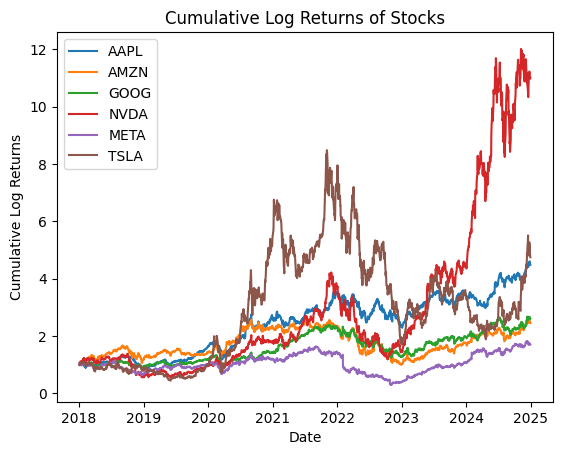

In [51]:

plt.figure()

for name in stock_names:
    stock_data = stock_df[stock_df["Symbol"] == name].dropna(subset=["Cumulative Log Return"])
    plt.plot(stock_data["Date"], stock_data["Cumulative Log Return"], label=name)

plt.title("Cumulative Log Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Returns")
plt.legend()
plt.show()



## Daily realized variance

In the first paper, $RV_t$ is used to estimate $QV$

This relies on interday measures: specifically looking at 5-min intervals

yfinance has limitations: provides daily info if want data from large period; 5min info only for a few days in the past.

Alternative option is [Parkinson's](https://www.ivolatility.com/education/parkinsons-historical-volatility/) which uses high/low data. See also [here](https://medium.com/@tanapon.chamn/parkinson-volatility-model-simulation-analysis-be32dcc35c35).

The second paper uses a rolling historical volatility, which is doable with the above data

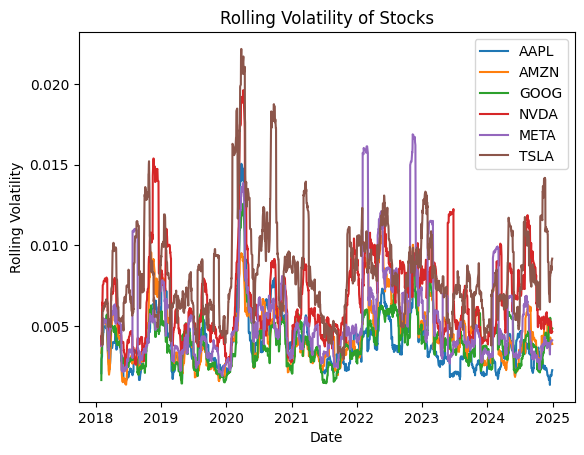

In [61]:
WINDOW = 21 # rolling window, number of days for volatility calc
DENOM = np.sqrt(1/(WINDOW-1))

stock_df['Rolling Volatility'] = (
    stock_df.groupby('Symbol')['Log Return']
      .transform(lambda x: x.rolling(WINDOW).std() * DENOM)
)


plt.figure()

for name in stock_names:
    stock_data = stock_df[stock_df["Symbol"] == name].dropna(subset=["Rolling Volatility"])
    plt.plot(stock_data["Date"], stock_data["Rolling Volatility"], label=name)

plt.title("Rolling Volatility of Stocks")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()


In [63]:
# calculate additional features

stock_df['Rolling Mean'] = (
    stock_df.groupby('Symbol')['Log Return']
      .transform(lambda x: x.rolling(WINDOW).mean())
)

stock_df['Absolute Log Return'] = (
    stock_df.groupby('Symbol')['Log Return']
      .transform(lambda x: np.abs(x))
)

stock_df['Future Volatility'] = (
    stock_df.groupby('Symbol')['Log Return']
      .transform(lambda x: x[::-1]
                   .rolling(WINDOW)
                   .std()[::-1]
                   .shift(-WINDOW + 1))
)

In [78]:
features = ["Rolling Mean", "Rolling Volatility", "Absolute Log Return"]
target = "Future Volatility"
train = stock_df.dropna(subset=features + [target])

X = train[features]
y = train[target]

meta = train[['Date', 'Symbol']] # keep track of metadata

# train/test split
split_date = '2023-01-01'

train_mask = train['Date'] < split_date

X_train = X[train_mask]
X_test  = X[~train_mask]

y_train = y[train_mask]
y_test  = y[~train_mask]

meta_test = meta[~train_mask]

In [79]:
# random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [80]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, pred))
print(rmse)

0.00997346499602907


In [86]:
results = meta_test.copy()
results['predicted_vol'] = pred
results['realized_vol'] = y_test.values
results.head()

Price,Date,Symbol,predicted_vol,realized_vol
7554,2023-01-03,AAPL,0.023782,0.016012
7555,2023-01-03,AMZN,0.026101,0.029294
7556,2023-01-03,GOOG,0.020111,0.030662
7557,2023-01-03,META,0.031664,0.050388
7558,2023-01-03,NVDA,0.032261,0.042435


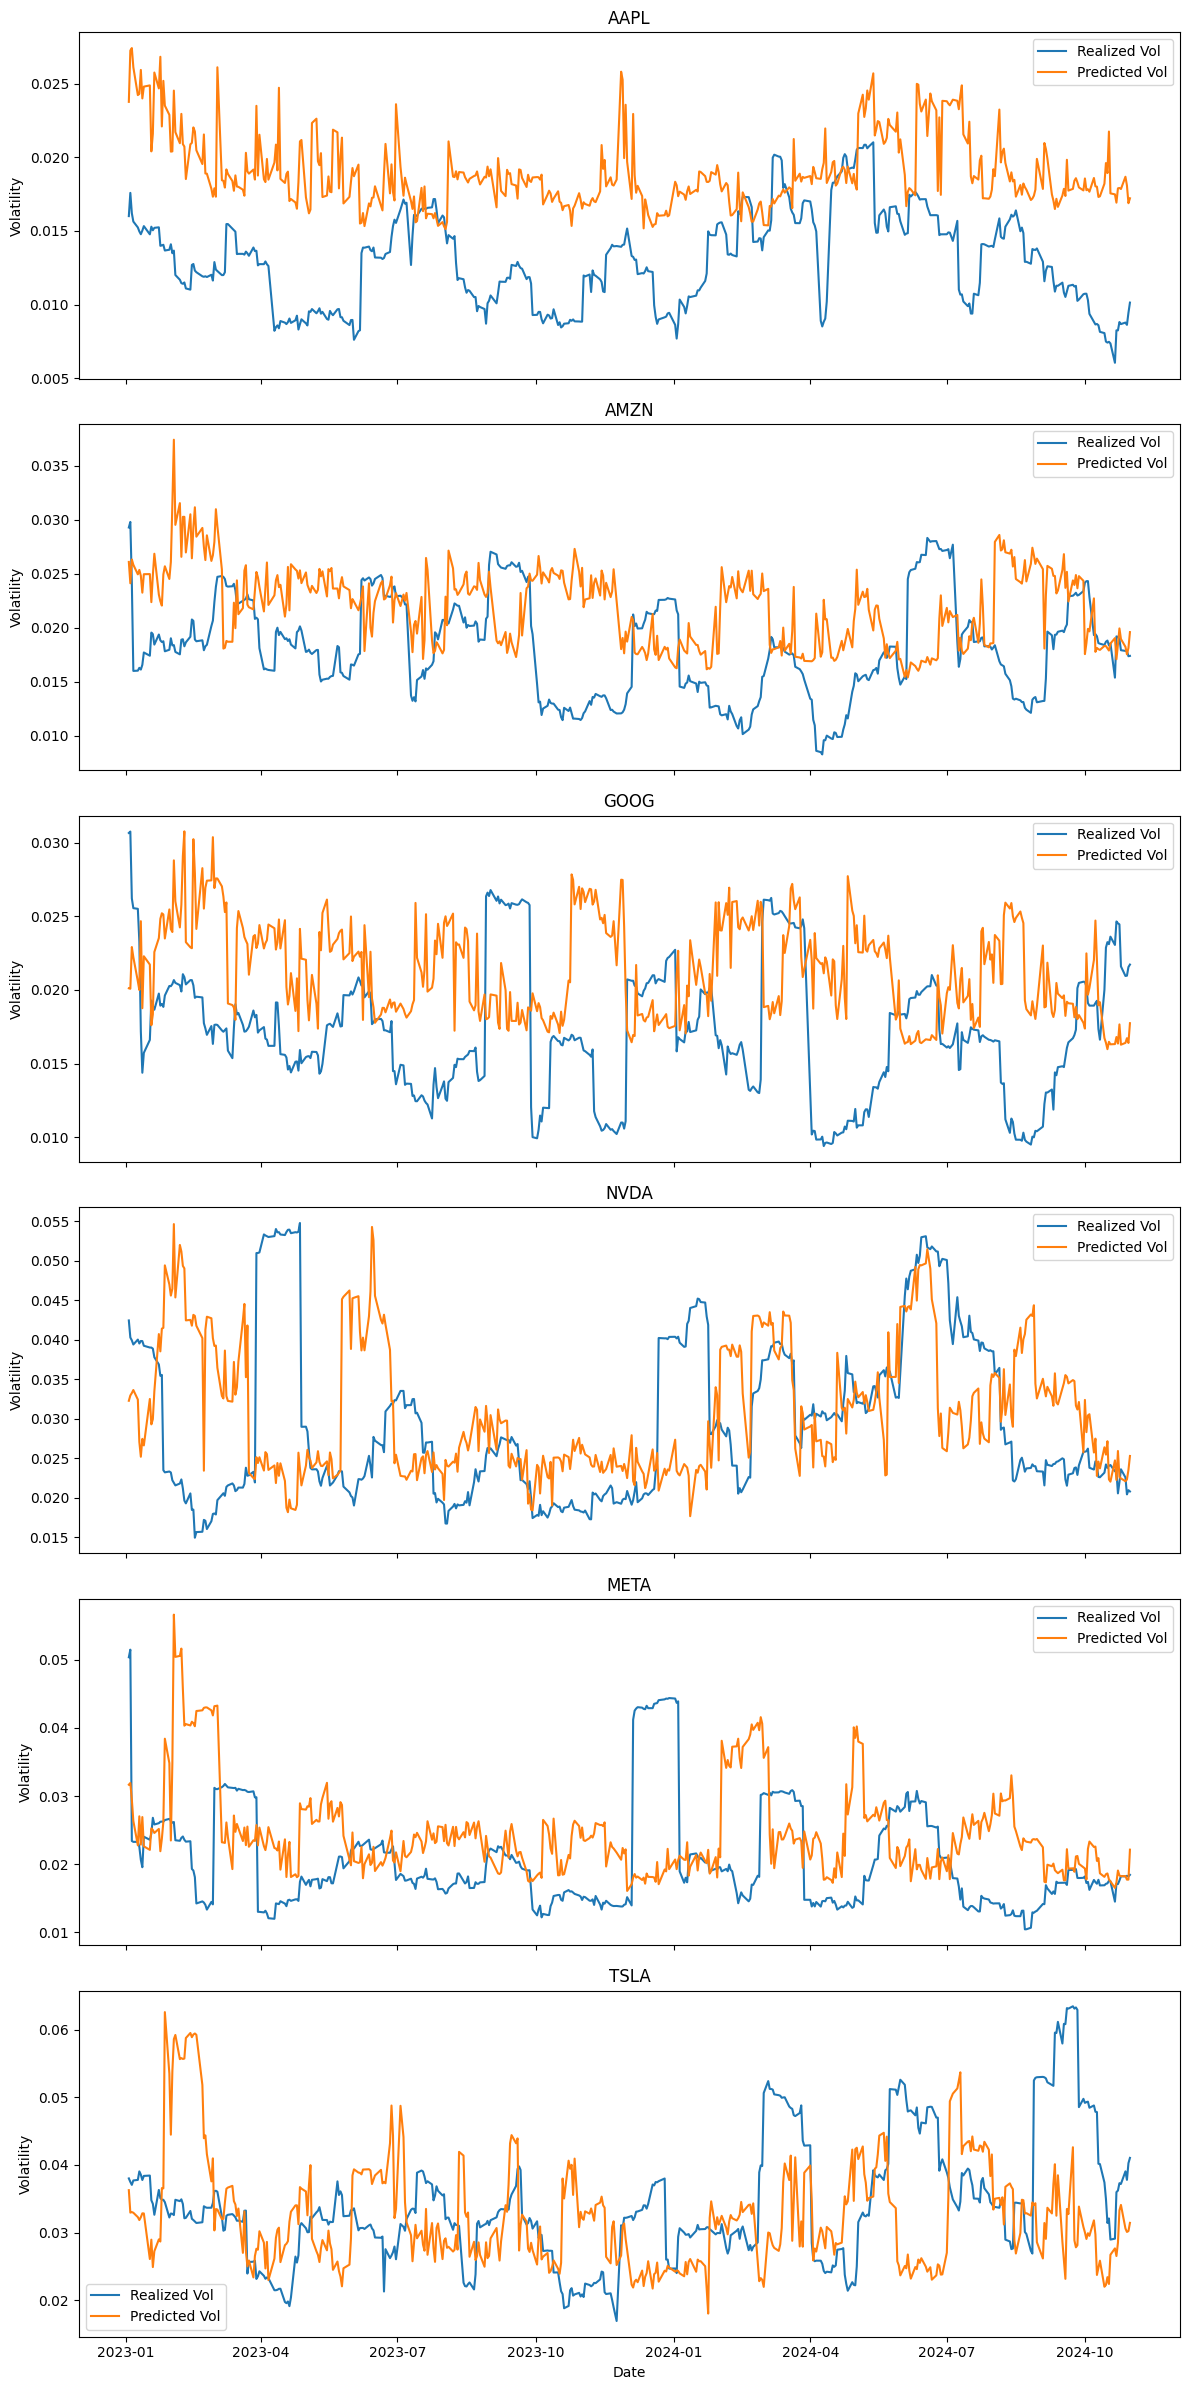

In [91]:
results = results.sort_values('Date')

fig, axes = plt.subplots(len(stock_names), 1, figsize=(12, 4 * len(stock_names)), sharex=True)

if len(stock_names) == 1:
    axes = [axes]

for i, name in enumerate(stock_names):
    ax = axes[i]

    stock_data = results[results["Symbol"] == name].dropna(subset=["realized_vol", "predicted_vol"])

    ax.plot(stock_data["Date"], stock_data["realized_vol"], label="Realized Vol")
    ax.plot(stock_data["Date"], stock_data["predicted_vol"], label="Predicted Vol")

    ax.set_title(name)
    ax.set_ylabel("Volatility")
    ax.legend()

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

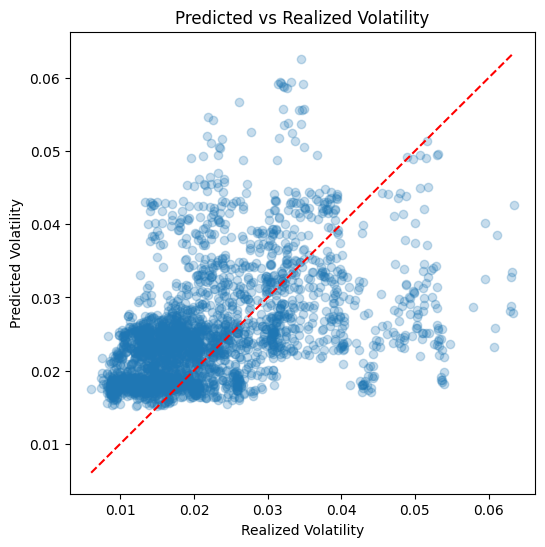

In [92]:
plt.figure(figsize=(6,6))

plt.scatter(
    results["realized_vol"],
    results["predicted_vol"],
    alpha=0.25
)

minv = min(results["realized_vol"].min(), results["predicted_vol"].min())
maxv = max(results["realized_vol"].max(), results["predicted_vol"].max())

plt.plot([minv, maxv], [minv, maxv], "r--")

plt.title("Predicted vs Realized Volatility")
plt.xlabel("Realized Volatility")
plt.ylabel("Predicted Volatility")
plt.show()

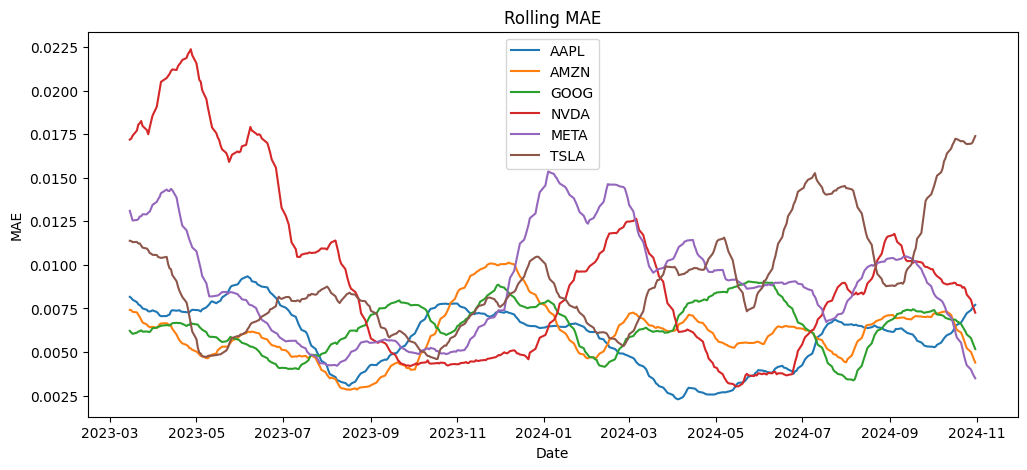

In [95]:
results["abs_error"] = (
    results["predicted_vol"] - results["realized_vol"]
).abs()

results["rolling_mae"] = (
    results.groupby("Symbol")["abs_error"]
    .transform(lambda x: x.rolling(50).mean())
)

plt.figure(figsize=(12,5))

for name in stock_names:
    stock = results[results["Symbol"] == name]
    plt.plot(stock["Date"], stock["rolling_mae"], label=name)

plt.title("Rolling MAE")
plt.xlabel("Date")
plt.ylabel("MAE")
plt.legend()
plt.show()

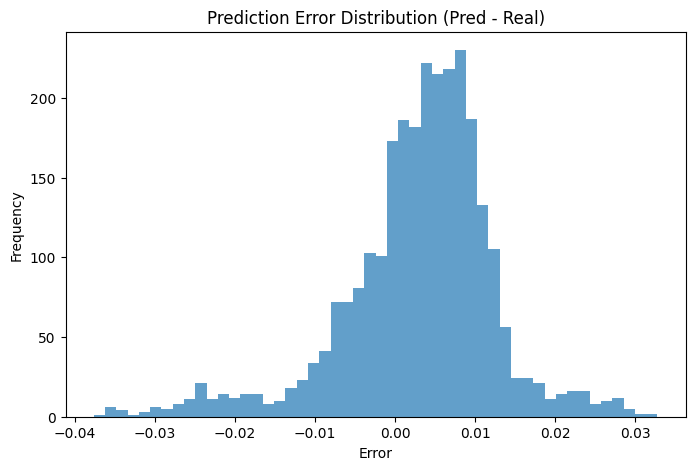

In [96]:
plt.figure(figsize=(8,5))

plt.hist(results["predicted_vol"] - results["realized_vol"], bins=50, alpha=0.7)

plt.title("Prediction Error Distribution (Pred - Real)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [97]:
bias = (
    results.groupby("Symbol")
    .apply(lambda x: (x["predicted_vol"] - x["realized_vol"]).mean())
)

print(bias)

Symbol
AAPL    0.006013
AMZN    0.003835
GOOG    0.004284
META    0.004067
NVDA    0.001477
TSLA   -0.001664
dtype: float64


C:\Users\Owner\AppData\Local\Temp\ipykernel_11108\3995454199.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["predicted_vol"] - x["realized_vol"]).mean())


## Features that might be important

- Daily quadratic variation
    - Estimated with $RV_t$
    - Issue: don't have granular enough data
    - Could try rolling quadratic variation: $RQV_t = \sqrt{\sum_{i=0}^m(r_{i+1}-r_i)^2}$ with $m$ window length
- Rolling volatility
    - Calculated by $data.rolling(window).std() * np.sqrt(252)$
    - Goal is to estimate this with "window"-length lookahead
- Volatility forecasting [article](https://www.tandfonline.com/doi/full/10.1080/14697688.2025.2454623#d1e490) and [guide](https://saltfinancial.com/static/uploads/2021/05/The%20Laymans%20Guide%20to%20Volatility%20Forecasting.pdf)
    - Parkinson's volatility
        - $\sigma = \sqrt{\frac{1}{4N\ln(2)}\sum_{i=1}^N(\ln(H_i/L_i))^2}$ for $N$ time period, $H_i, L_i$ high/low data at time $t=i$ 
    - Historical close-close volatility:
        - For $L$ number of days, $HV_d = \sqrt{\frac{1}{L-1}\sum_{t=0}^{L-1}\ln(C_{d-t}/C_{d-1-t})^2}$
    - Garman-Klass estimator:
        - $GK_d = \sqrt{\frac{1}{L}\sum_{t=0}^{L-1}\left(\frac{1}{2}(\ln(H_{d-l}/L_{d-l})^2-(2\ln(2)-1)(\ln(C_{d-1}/O_{d-l})^2\right)}$ for $O_t, C_t$ open and close price
    - Above three assumes zero drift
    - Rogers-Satchell: accomodates nonzero drift
    - GKYZ: accounts for overnight jumps
    - VIX-fix: volatility proxy
    - EWMA: $\sigma^2 = (1-\lambda)\sum_{t=1}^n\lambda^{t-1}r_t^2$ for $\lambda < 1$, usually $\lambda = 0.94$ for daily data
- Can look at MACD/RSI
- Forecasting with RF [paper](https://econjournals.com/index.php/ijefi/article/view/15431)
    - Stochastic oscillator, williams percentage range, on balance volume also options
    - Paper excludes SO and WPR because have low correlation with dependent variable
    - Evaluate using MAE, MSE, RMSE, MAPSE, and R-squared
- Use 80/20 split and gridsearch for hyperparameter tuning: [tutorial](https://medium.com/cloudvillains/random-forest-with-grid-search-b739fb0da311)

In [4]:
# create class that handles RF implementation
import sys
from pathlib import Path

# notebook directory
notebook_dir = Path().resolve()

# project root = one level up from notes/
project_root = notebook_dir.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [5]:
import importlib
import model.RF_model as rf

importlib.reload(rf)

<module 'model.RF_model' from 'C:\\Users\\Owner\\code\\erdos-2026-volatility-models\\ML_model\\model\\RF_model.py'>

In [6]:
# see if model works at all
stock_names = ["AAPL", "AMZN", "GOOG", "NVDA", "META", "TSLA"]
start_date = "2018-01-01"
end_date = "2024-12-31"
window = 21
target_window = 5

model = rf.RF_Model(stock_names, window, start_date, end_date, features=None, target_window=target_window, grid_search=True)

[*********************100%***********************]  6 of 6 completed
C:\Users\Owner\code\erdos-2026-volatility-models\ML_model\model\RF_model.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  self.stock_data.stack(level=1)


In [7]:
model.det_features()

model.fit_RF()

metrics = model.test_results()

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [8]:
print("Final features: ", model.final_features)
print("Starting features: ", model.features)
print("RF params: ", model.rf_params)
print("target: ", model.target)

for k, v in metrics.items():
    print(f"{k} = {v}")

Final features:  ['parkinson_vol', 'rv_63', 'obv', 'rsi', 'vix_fix', 'macd', 'rv_5', 'bb_width', 'ewma', 'adx', 'cmf', 'rolling_vol', 'macd_hist', 'atr']
Starting features:  ['rolling_vol', 'parkinson_vol', 'close_close_vol', 'GK_vol', 'GKYZ', 'vix_fix', 'ewma', 'macd', 'macd_signal', 'macd_hist', 'rsi', 'adx', 'atr', 'bb_width', 'obv', 'cmf', 'rv_5', 'rv_21', 'rv_63']
RF params:  {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 500}
target:  target_real_vol_5
mse = 0.04113089982546069
rmse = 0.2028075438080662
mae = 0.1416105928729295
r2 = 0.06128526704100923
mape = 0.5625211422171413
bias = Symbol
AAPL    0.045627
AMZN    0.028983
GOOG    0.002221
META    0.133781
NVDA    0.092143
TSLA   -0.007494
dtype: float64


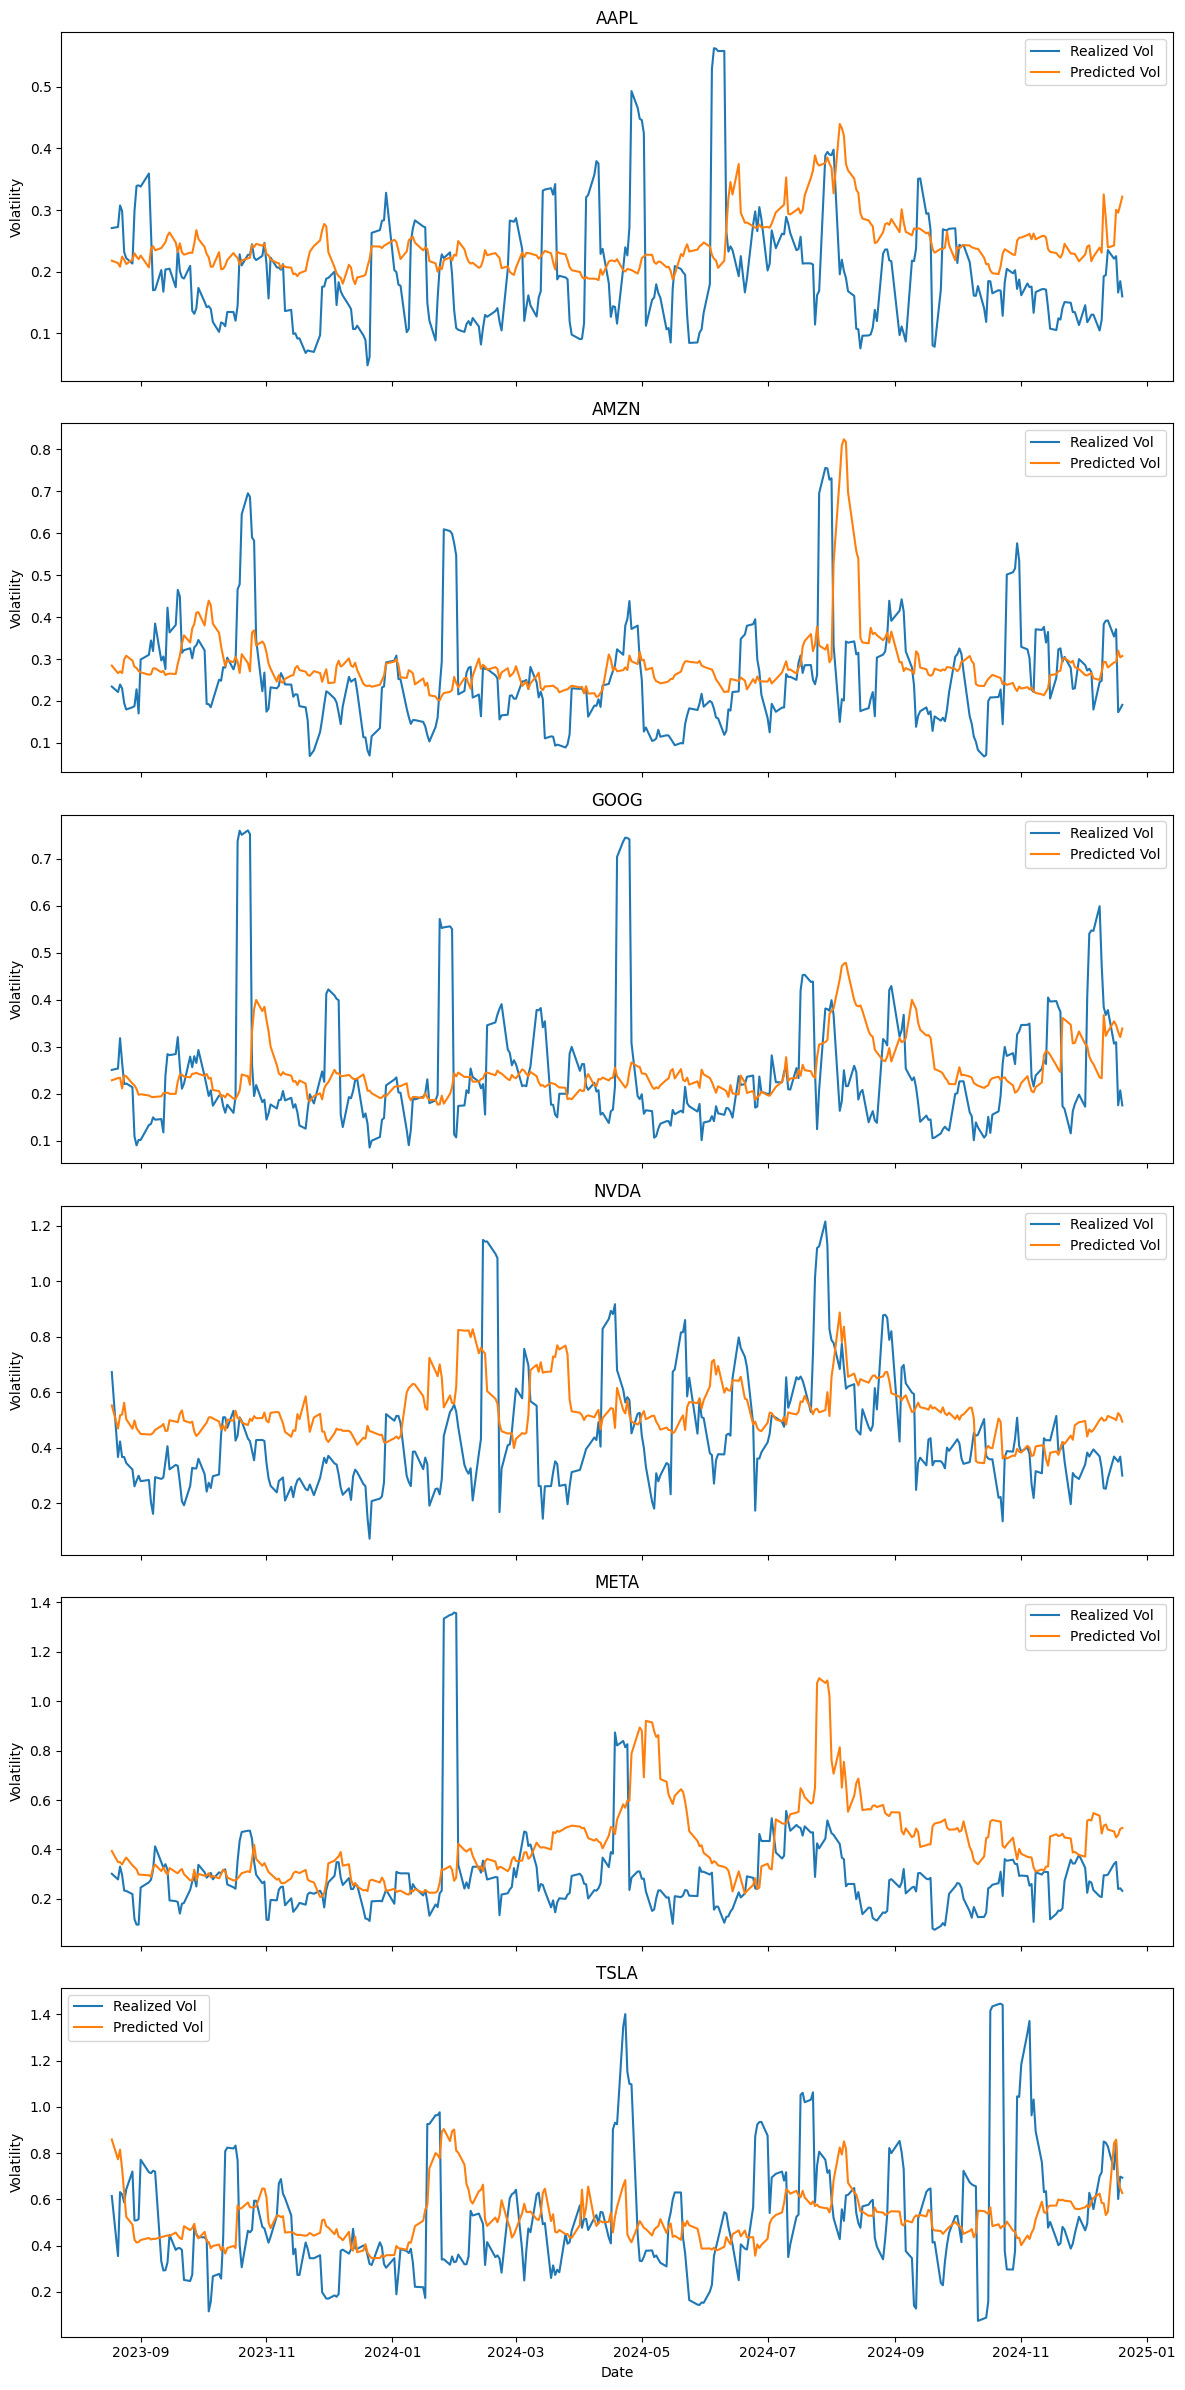

In [9]:
model.plot_results()

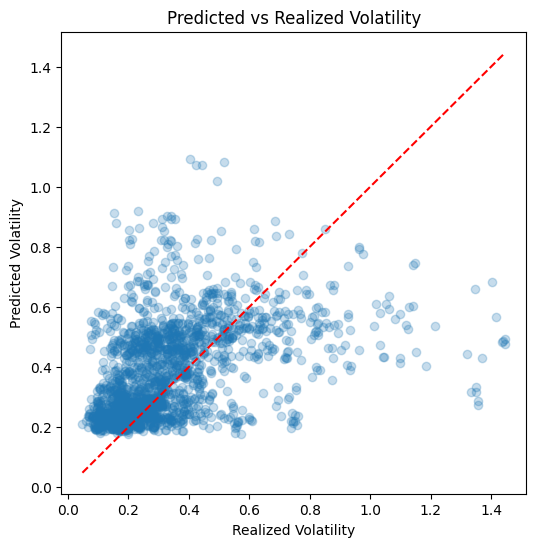

In [10]:
model.scatter()

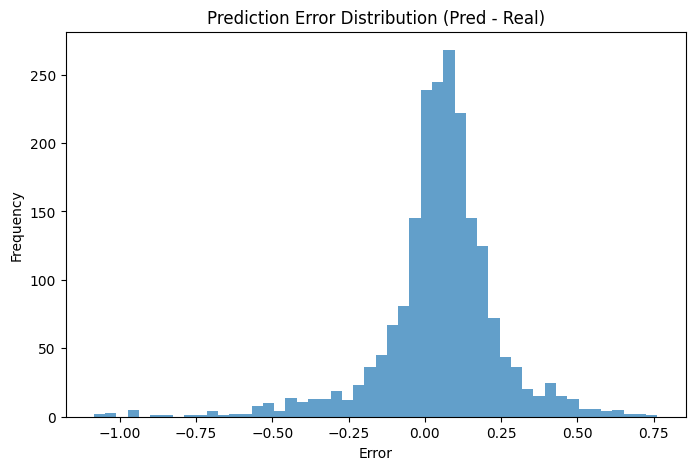

In [11]:
model.hist()

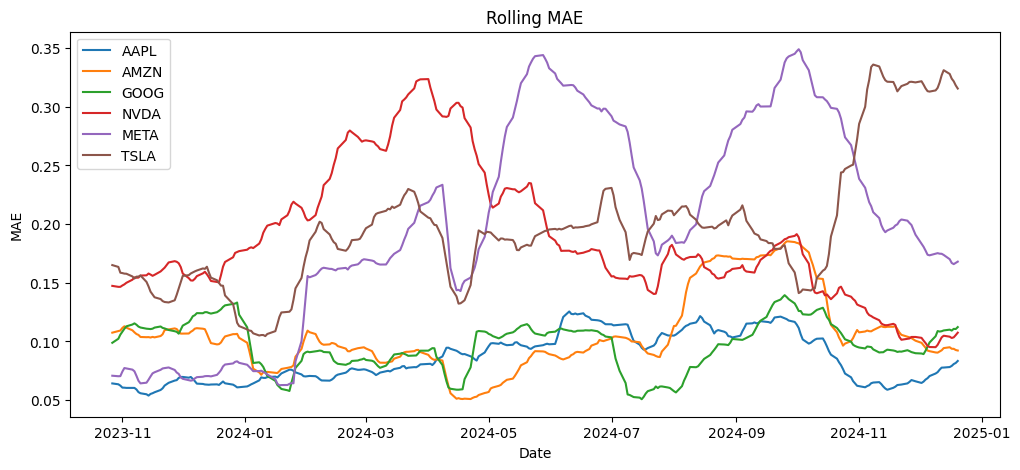

In [12]:
model.rolling_mae_plot()